# Modelos Generativos en Computer Vision

El siguiente notebook está dividido en 2 secciones:

1. Introducción a diffusers, stable diffusion y sus distintos modos, y manipulación y customización de esta arquitectura.
2. Cuestionario de evaluación.

**La primera sección no es evaluada**, es de caracter opcional y su objetivo es demostrar cómo utilizar y manipular modelos generativos del estado del arte.



---

## ✨ ✨ Introducción a diffusers y Stable Diffusion ✨ ✨




[Diffusers](https://huggingface.co/docs/diffusers/index) es una libería desarrollada el 2022 por HuggingFace, que busca facilitar y estandarizar el acceso al estado del arte de modelos de difusión.

La librería cuenta con tres componentes lógicos:

1. Diffusion Pipelines (procesos de difusion).
2. Noise Schedulers (programadores de ruido).
3. Modelos pre-entrenados.

De manera general, un pipeline de difusión se refiere a una arquitectura de difusión (por ejemplo, Stable Difusion). Por otro lado, el scheduler de ruido maneja cómo se realiza el proceso de difusión dentro de una pipeline, lo cual influye en aspectos como la velocidad que toma hacer una imagen, o bien la calidad final de esta. Finalmente, un modelo pre-entrenado es simplemente una pipeline que ya fue entrenada, y en varios casos, también incluye o limita el número de schedulers disponibles.

# Accediendo a Stable Diffusion mediante diffusers

La primera arquitectura expuesta en diffusers fue Stable Diffusion, por lo que en la actualidad, cuenta con bastante soporte y utilidades para este modelo.

Así que no perdamos el tiempo y comencemos a jugar con él. 😊

## Instalación de librerías necesarias

Comencemos instalando las librerías que utilizaremos.

In [1]:
!pip install diffusers transformers accelerate mediapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 52.0 MB/s eta 0:00:00


In [2]:
import torch
from diffusers import DiffusionPipeline
import mediapy as media

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# Stable Diffusion 101

Ahora que instalamos las librerías necesarias, ¡generemos imágenes!

In [3]:
pipeline = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16).to("cuda")
# Descargamos y cargamos nuestro pipeline
# Este proceso toma tiempo, tiene que descargar los pesos del modelo

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


""

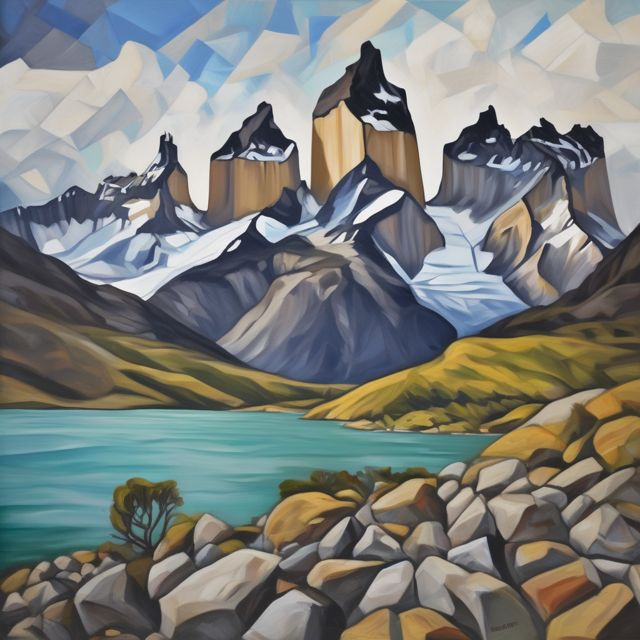

In [4]:
generator = torch.Generator(device="cuda")

prompt = "An oil painting of Torres del Paine, painted in the cubist style of picasso" # descripción de la imagen a generar

images = pipeline(prompt, generator=generator).images # generamos una imagen y retornamos los resultados

media.show_images(images) # mostramos la imagen

Así de simple es generar una imagen. 🤯

Veamos qué involucró nuestro código:

- `DiffusionPipeline` es la clase de diffusers que permite acceder a una arquitectura.
- `from_pretrained` recibe un string indicando los pesos a cargar. Esto además informa a `DiffusionPipeline` que arquitectura será utilizada.
- `torch_dtype` informa qué representación de punto flotante queremos utilizar. Este modelo fue entrenado con una representación de `float32`, pero estamos bajando a `float16` dado que utiliza menos memoria en la GPU y la generación es más rápida. Existen incluso versiones de 8 y 4 bits.
- `pipeline("A painting of Torres del Paine, painted in the cubist style of picasso")` genera la imagen condicionada con el texto _"A painting of Torres del Paine, painted in the cubist style of picasso"_.

En esta ocasión, utilizamos la versión 1.5 de esta arquitectura, dado que es la que cuenta con más desarrollo de parte de la comunidad. Ojo que hace aproximadamente un mes salió Stable Diffusion XL, la cual es bastante superior a esta versión. En caso de que quieran saber qué otros modelos pre-entrenados existen, diffusers presenta [éste indice](https://huggingface.co/models).

Veamos ahora los parametros de manipulación que presenta nuestra pipeline.

En primer lugar, cambiemos los pasos de inferencia.

  0%|          | 0/25 [00:00<?, ?it/s]

""

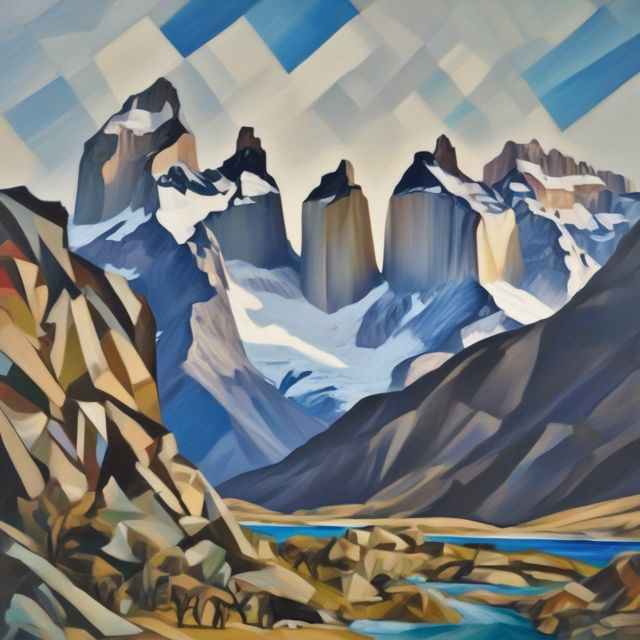

In [5]:
def generate_image(steps, prompt=prompt):

  generator = torch.Generator(device="cuda").manual_seed(32)

  images = pipeline(prompt, generator=generator, num_inference_steps=steps).images

  media.show_images(images)

generate_image(steps=25)

Como podemos ver `num_inference_steps` determina la cantidad de pasos que realizará el proceso de difusión. Por default este modelo utiliza 50 pasos.

Veamos que ocurre si bajamos aún más la cantidad de pasos.

  0%|          | 0/5 [00:00<?, ?it/s]

""

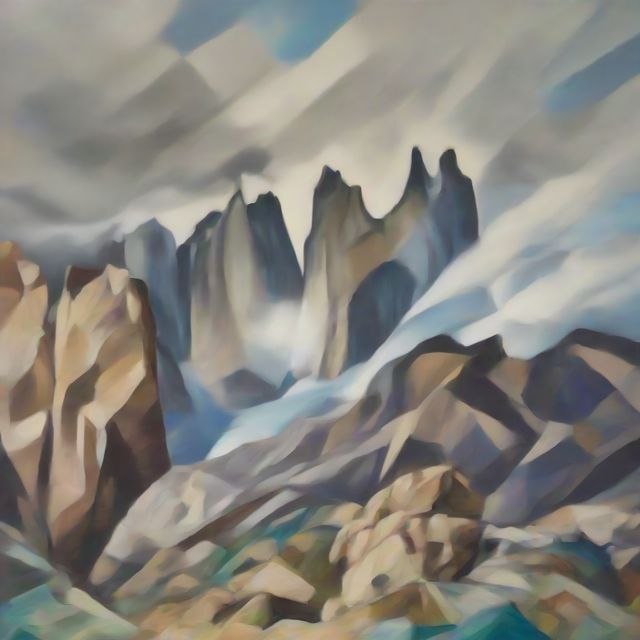

In [6]:
generate_image(steps=5)

La imagen tomó mucho menos tiempo en generarse, pero bajó notoriamente su calidad.

¿Que ocurre si aumentamos la cantidad de pasos?

  0%|          | 0/100 [00:00<?, ?it/s]

""

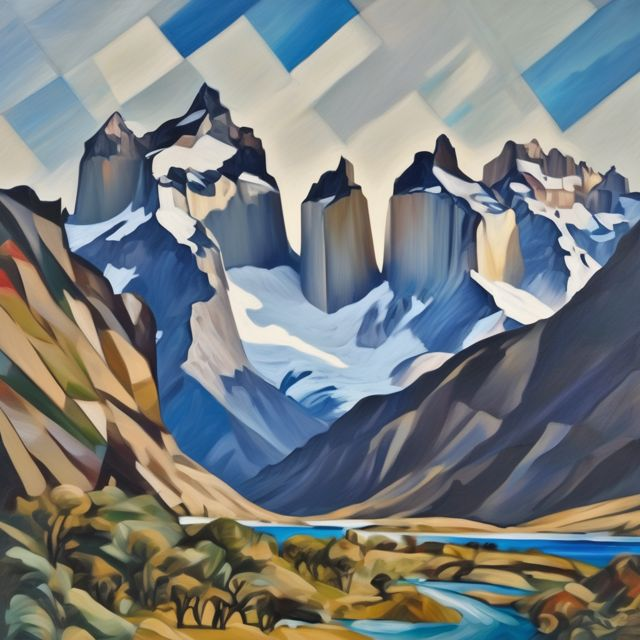

In [7]:
generate_image(steps=100)

  0%|          | 0/200 [00:00<?, ?it/s]

""

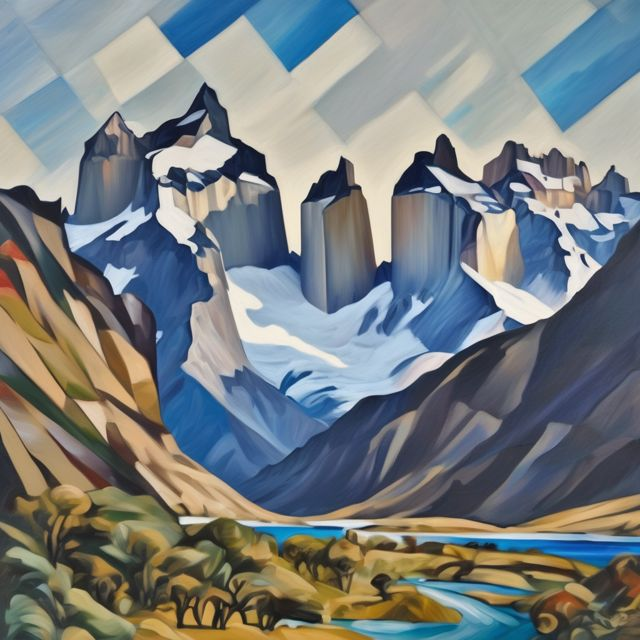

In [8]:
generate_image(steps=200)

A medida que aumenta la cantidad de pasos, los detalles de la imagen final también aumentan (con prompts sobre imágenes más reales se nota mejor este efecto). De todas formas, esto tiene un límite y si bien uno puede poner numeros muy grandes de steps, la imagen final no mejorará mucho más que lo alcanzable entre 100-200 steps.

Probemos ahora los noise schedulers.

En primer lugar, veamos qué noise scheduler utiliza stable diffusion por default, y los schedulers compatibles.

In [9]:
print("Stable Diffusion scheduler:", pipeline.scheduler)

print("listado de schedulers compatibles:")
for scheduler in pipeline.scheduler.compatibles:
  print(scheduler)

Stable Diffusion scheduler: EulerDiscreteScheduler {
  "_class_name": "EulerDiscreteScheduler",
  "_diffusers_version": "0.38.0",
  "beta_end": 0.012,
  "beta_schedule": "scaled_linear",
  "beta_start": 0.00085,
  "clip_sample": false,
  "final_sigmas_type": "zero",
  "interpolation_type": "linear",
  "num_train_timesteps": 1000,
  "prediction_type": "epsilon",
  "rescale_betas_zero_snr": false,
  "sample_max_value": 1.0,
  "set_alpha_to_one": false,
  "sigma_max": null,
  "sigma_min": null,
  "skip_prk_steps": true,
  "steps_offset": 1,
  "timestep_spacing": "leading",
  "timestep_type": "discrete",
  "trained_betas": null,
  "use_beta_sigmas": false,
  "use_exponential_sigmas": false,
  "use_karras_sigmas": false
}

listado de schedulers compatibles:
<class 'diffusers.schedulers.scheduling_dpmsolver_multistep.DPMSolverMultistepScheduler'>
<class 'diffusers.schedulers.scheduling_pndm.PNDMScheduler'>
<class 'diffusers.schedulers.scheduling_dpmsolver_singlestep.DPMSolverSinglestepSchedu

Probemos con 3 schedulers distintos.

<class 'diffusers.schedulers.scheduling_deis_multistep.DEISMultistepScheduler'>


  0%|          | 0/50 [00:00<?, ?it/s]

""

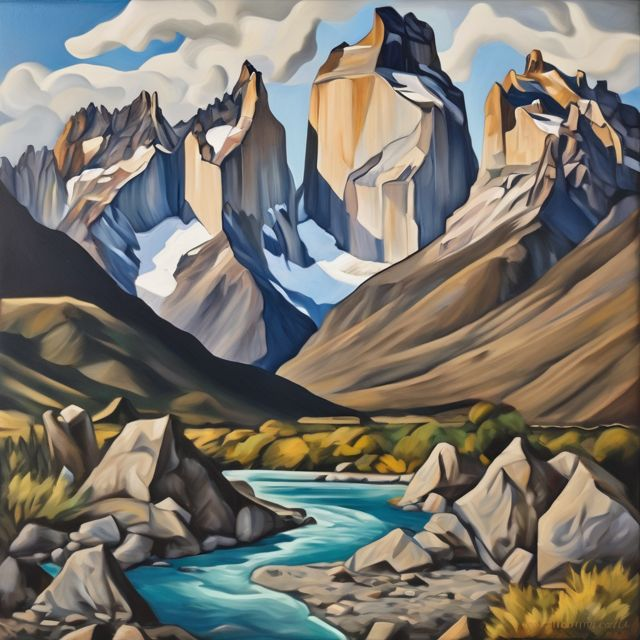

<class 'diffusers.schedulers.scheduling_deis_multistep.DEISMultistepScheduler'>


  0%|          | 0/50 [00:00<?, ?it/s]

""

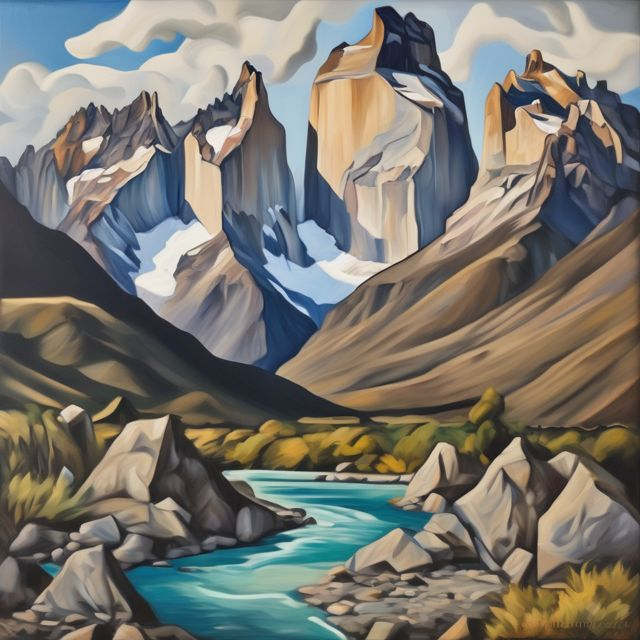

<class 'diffusers.schedulers.scheduling_deis_multistep.DEISMultistepScheduler'>


  0%|          | 0/50 [00:00<?, ?it/s]

""

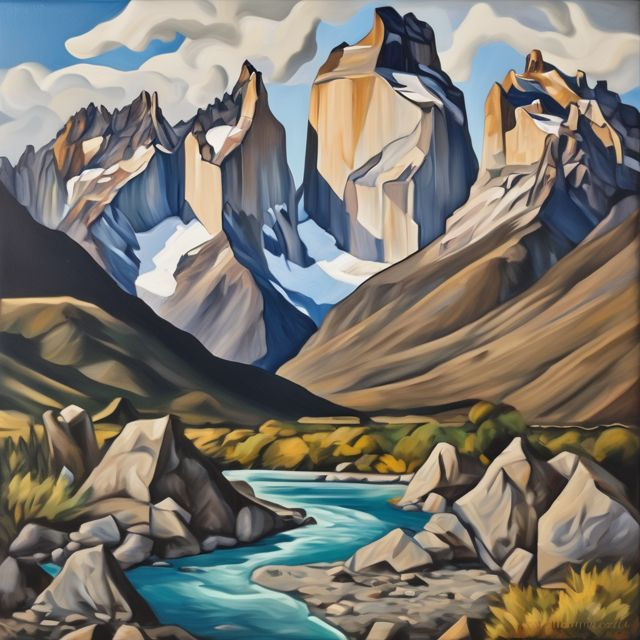

<class 'diffusers.schedulers.scheduling_deis_multistep.DEISMultistepScheduler'>


  0%|          | 0/50 [00:00<?, ?it/s]

""

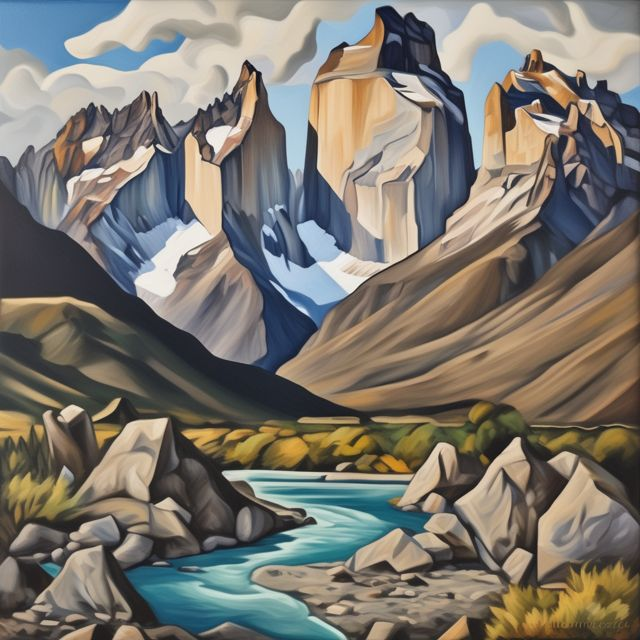

In [10]:
from diffusers import LMSDiscreteScheduler, EulerDiscreteScheduler, KDPM2DiscreteScheduler, UniPCMultistepScheduler

def generate_image(scheduler, prompt=prompt):
  generator = torch.Generator(device="cuda").manual_seed(42)

  scheduler = scheduler.from_config(pipeline.scheduler.config)
  pipeline.scheduler = scheduler

  images = pipeline(prompt, generator=generator).images

  media.show_images(images)

print(scheduler)
generate_image(LMSDiscreteScheduler)
print(scheduler)
generate_image(EulerDiscreteScheduler)
print(scheduler)
generate_image(KDPM2DiscreteScheduler)
print(scheduler)
generate_image(UniPCMultistepScheduler)

Como podemos ver, cambia sutilmente los detalles según el sampler. Además, los tiempos de inferencia son distintos para cada samples. La pregunta obvia es, ¿cuál sampler utilizar?

En la práctica, es mejor probar distintos samplers según la imagen a generar, ya que son situacionales.

Por último, veamos la `guidance_scale`.

Guidance scale: 0


  0%|          | 0/20 [00:00<?, ?it/s]

""

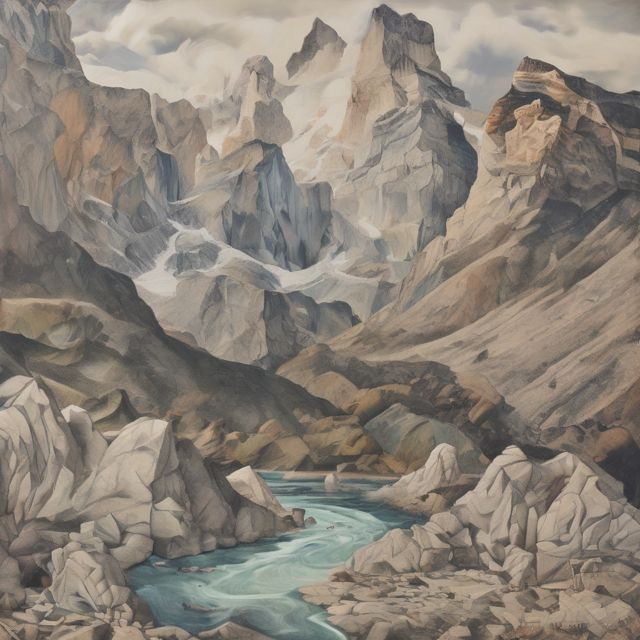

Guidance scale: 5


  0%|          | 0/20 [00:00<?, ?it/s]

""

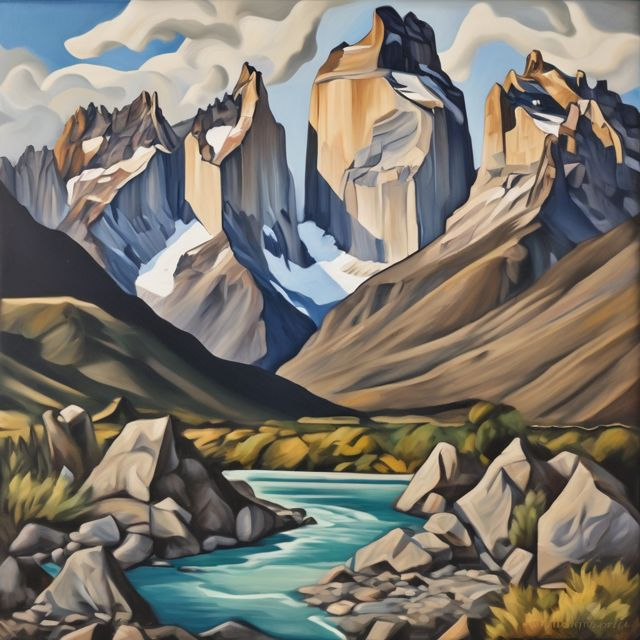

Guidance scale: 10


  0%|          | 0/20 [00:00<?, ?it/s]

""

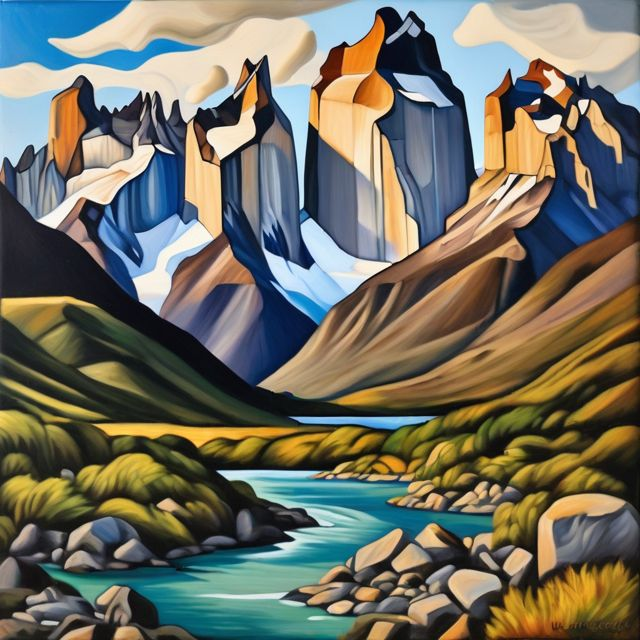

Guidance scale: 40


  0%|          | 0/20 [00:00<?, ?it/s]

""

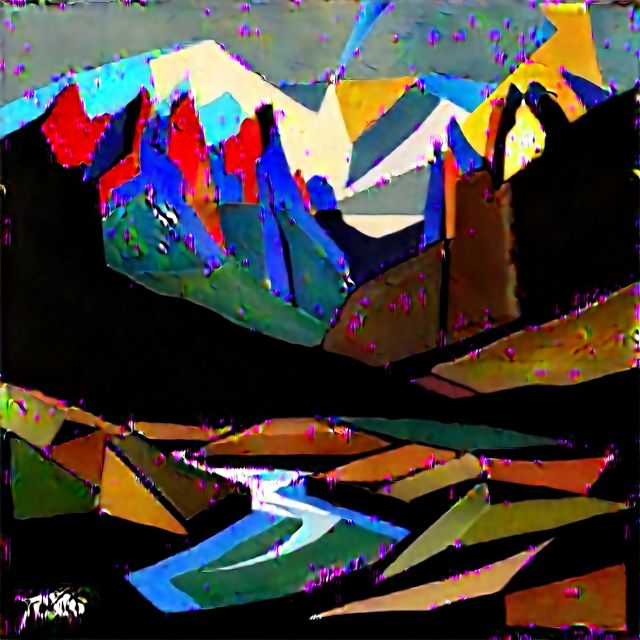

In [11]:
# prompt sigue siendo "An oil painting of Torres del Paine, painted in the cubist style of picasso"
def generate_image(guidance_scale, steps=20, prompt=prompt, scheduler=LMSDiscreteScheduler):
  generator = torch.Generator(device="cuda").manual_seed(42)

  scheduler = scheduler.from_config(pipeline.scheduler.config)
  pipeline.scheduler = scheduler

  images = pipeline(prompt, generator=generator, num_inference_steps=steps, guidance_scale=guidance_scale).images

  media.show_images(images)

for guidance_scale in [0, 5, 10, 40]:
  print("Guidance scale:", guidance_scale)
  generate_image(guidance_scale=guidance_scale)


La `guidance_scale` controla la "libertad" que tiene el modelo al momento de generar una imagen dado un prompt. El valor estandar es 7.5, valores más bajos que estos implican que el modelo podrá "alejarse" con mayor libertad del contenido del prompt, mientras que valores altos, obligan al modelo a intentar replicar fielmente el "prompt".

# Modos alternativos de Stable Diffusion

Ahora que tenemos una mayor comprensión de cómo utilizar stable diffusion, veamos pipelines alternativas creadas por la comunidad.

## Img2Img

Img2img es un modo que permite condicionar la generación de una imagen con un prompt y otra imagen. Esto se logra agregando ruido a la imagen entregada, y quitando este ruido con el proceso condicionado mediante el texto entregado.

In [12]:
from diffusers import StableDiffusionImg2ImgPipeline
import gc
import torch

gc.collect()          # Limpia la basura de Python
torch.cuda.empty_cache()  # Libera la memoria RAM de la tarjeta de video (GPU)

pipeline = StableDiffusionImg2ImgPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16).to("cuda")
# Este proceso tambien tomara tiempo, ya que debe descargar los pesos

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

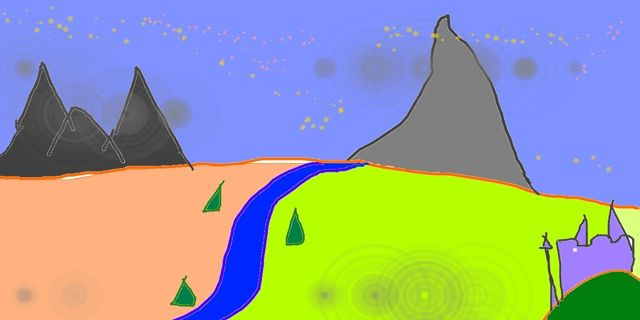

In [13]:
from diffusers.utils import load_image

url = "https://raw.githubusercontent.com/CompVis/stable-diffusion/main/assets/stable-samples/img2img/sketch-mountains-input.jpg"

init_image = load_image(url)
init_image

  0%|          | 0/40 [00:00<?, ?it/s]

""

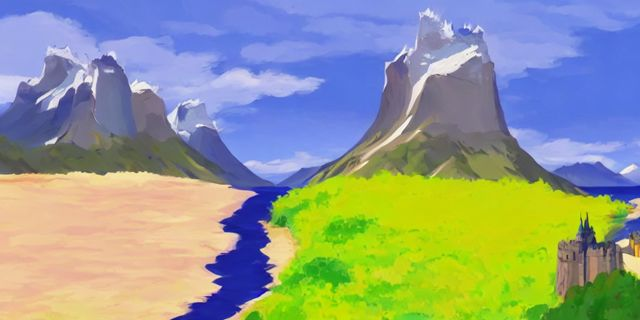

In [14]:
prompt = "Painting in the style of studio ghibli movies, featuring Torres del Paine with a castle"
generator = torch.Generator(device="cuda").manual_seed(42)

scheduler = scheduler.from_config(pipeline.scheduler.config)
pipeline.scheduler = scheduler

images = pipeline(prompt, generator=generator, image=init_image).images

media.show_images(images)

## Inpainting

Inpainting se parece a img2img, con la diferencia que sólo edita la sección enmascarada de la imagen original.

In [15]:
from diffusers import StableDiffusionInpaintPipeline
import gc
import torch

gc.collect()          # Limpia la basura de Python
torch.cuda.empty_cache()  # Libera la memoria RAM de la tarjeta de video (GPU)

pipeline = StableDiffusionInpaintPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-inpainting",
    torch_dtype=torch.float16,
).to("cuda")

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

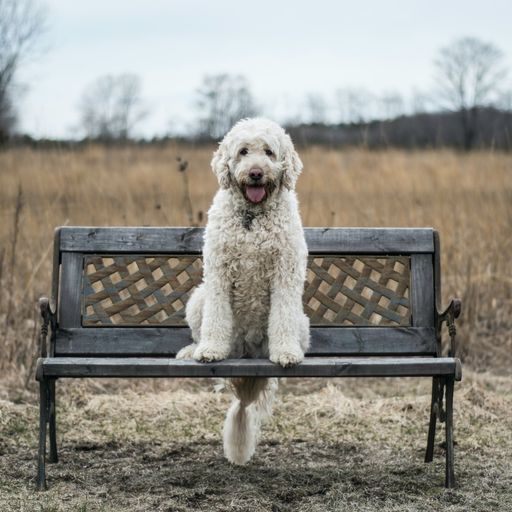

In [16]:
img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

init_image = load_image(img_url).resize((512, 512))
mask_image = load_image(mask_url).resize((512, 512))

init_image

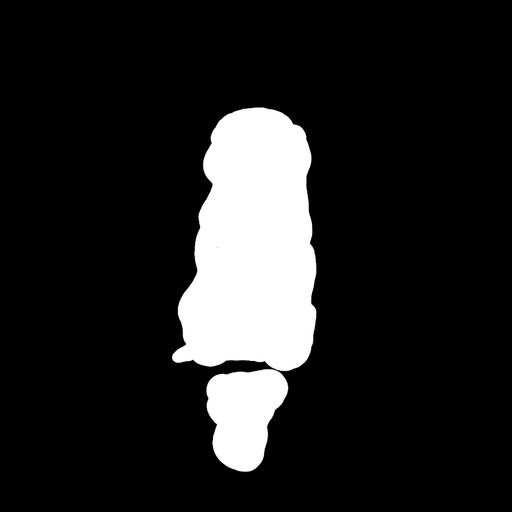

In [17]:
mask_image

  0%|          | 0/40 [00:00<?, ?it/s]

""

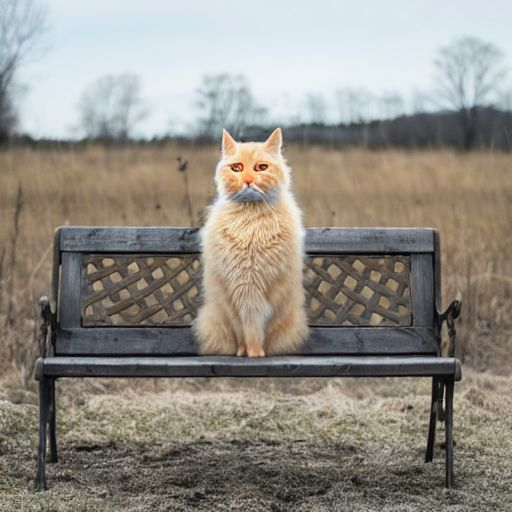

In [18]:
prompt = "A photorealistic cinematic fluffy orange cat sitting in a bench, highly detailed, 4k"
images = pipeline(prompt=prompt, image=init_image, mask_image=mask_image, strength=0.8).images
# Denoising Strenght
# 0.1 a 0.4 (Fuerza baja): Ideal para retoques sutiles o corregir imperfecciones (como arreglar un ojo o un dedo). El modelo respetará casi por completo la forma y colores del perro original.
# 0.5 a 0.7 (Fuerza media): Modifica la estructura pero mantiene los colores base. Podría intentar fusionar la forma del perro con el gato.
# 0.75 a 0.9 (Fuerza alta): Destruye la información visual del perro dentro de la máscara y recrea un gato desde cero, pero usando los bordes de la máscara para integrarlo perfectamente con la banca.
# 1.0 (Fuerza máxima): Ignora por completo lo que había abajo de la máscara y dibuja el prompt basándose solo en el ruido aleatorio.

media.show_images(images)

##### ControlNet

ControlNet es un sistema que permite condicionar la generación de una imágen en stable diffusion, mediante condicionantes aprendidos. En este caso, veremos cómo permite generar imágenes utilizando los ejes/contornos de otra imagen.

In [23]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import gc, torch

# Borra el pipeline anterior solo si existe (evita el NameError)
try:
    del pipeline
except NameError:
    pass

# flush() no estaba definido; esto es lo que hace
gc.collect()
torch.cuda.empty_cache()

controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16)
pipeline = StableDiffusionControlNetPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", controlnet=controlnet, torch_dtype=torch.float16
).to("cuda")
pipeline.scheduler = UniPCMultistepScheduler.from_config(pipeline.scheduler.config)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

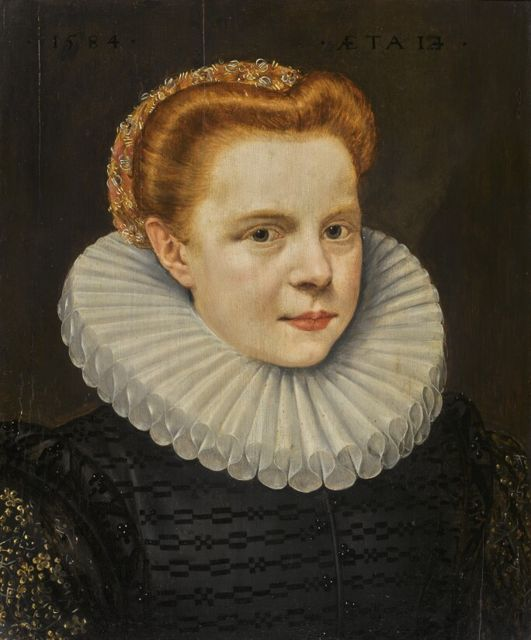

In [24]:
image = load_image(
    "https://sothebys-com.brightspotcdn.com/dims4/default/57548a3/2147483647/strip/true/crop/1660x2000+0+0/resize/684x824!/quality/90/?url=http%3A%2F%2Fsothebys-brightspot.s3.amazonaws.com%2Fdotcom%2Fe3%2Ff7%2Ffa9d2912443a863bc07d4a1a8ee2%2Fomp-3ofakind-2.jpg"
)
image

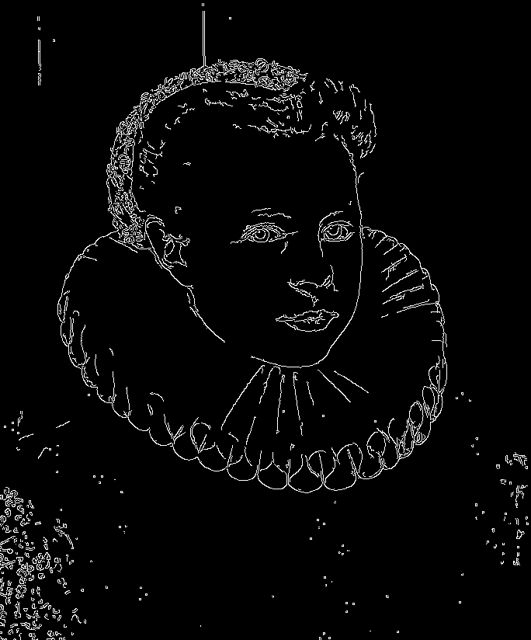

In [25]:
import cv2
from PIL import Image
import numpy as np

image = np.array(image)

low_threshold = 100
high_threshold = 200

image = cv2.Canny(image, low_threshold, high_threshold)
image = image[:, :, None]
image = np.concatenate([image, image, image], axis=2)
canny_image = Image.fromarray(image)
canny_image

In [26]:
def image_grid(imgs, rows, cols):
    assert len(imgs) == rows * cols

    w, h = imgs[0].size
    grid = Image.new("RGB", size=(cols * w, rows * h))
    grid_w, grid_h = grid.size

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i % cols * w, i // cols * h))
    return grid

In [27]:
prompt = ", best quality, extremely detailed"
prompt = [t + prompt for t in ["Gabriela Mistral", "Kim Kardashian", "rihanna", "taylor swift"]]

  0%|          | 0/20 [00:00<?, ?it/s]

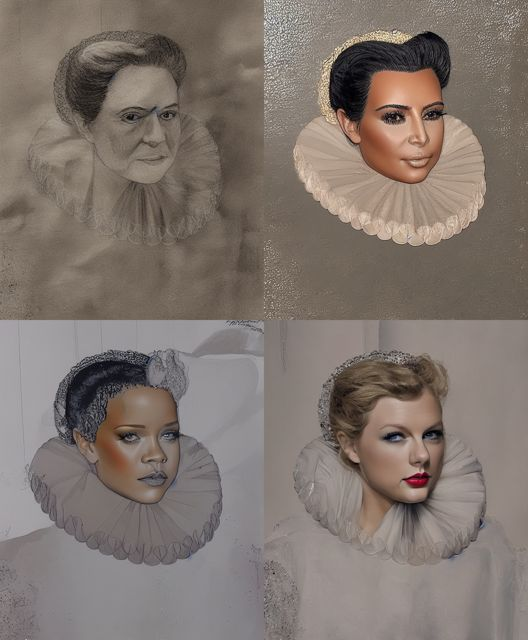

In [28]:
output = pipeline(
    prompt,
    canny_image,
    num_inference_steps=20
)

image_grid(output.images, 2, 2)

## Cuestionario de evaluación


### Pregunta 1 (4 pts)

Explica el "*Generative learning trilemma*". Menciona cada uno de sus elementos, y caracteristicas comparativas.



**Respuesta 1**

El **generative learning trilemma** (Xiao, Kreis & Vahdat, NVIDIA 2022, *"Tackling the Generative Learning Trilemma with Denoising Diffusion GANs"*) plantea que todo modelo generativo idealmente busca **tres propiedades a la vez**, pero las familias clásicas solo alcanzan **dos de las tres**:

1. **Alta calidad de muestras** — que lo generado sea realista y nítido, fiel a la distribución real (sin imágenes borrosas ni artefactos).
2. **Cobertura de modos / diversidad** — que el modelo capture toda la variedad de la distribución de datos, sin colapsar a unos pocos ejemplos (*mode collapse*).
3. **Muestreo rápido** — que generar una muestra sea computacionalmente barato (idealmente una sola pasada, no cientos de iteraciones).

### Características comparativas

| Familia | Calidad | Diversidad | Velocidad | Sacrifica |
|---|---|---|---|---|
| **GANs** | Alta | Baja (mode collapse) | Rápida (1 forward) | **diversidad** (+ entrenamiento inestable) |
| **VAEs / Normalizing Flows** | Menor (borrosas) | Buena | Rápida | **calidad** |
| **Modelos de difusión (DDPM)** | Alta | Alta | Lenta (cientos de pasos) | **velocidad** |

Ninguna familia clásica logra los tres vértices simultáneamente. Los **GANs** son rápidos y nítidos pero colapsan modos; los **VAEs** son diversos y rápidos pero borrosos; la **difusión** logra calidad **y** diversidad, pero su muestreo es lento porque requiere iterar el proceso de denoising muchas veces.

### Evidencia en el laboratorio

Con Stable Diffusion (difusión) esto se observa directamente: la calidad depende de `num_inference_steps` — con 5 pasos la imagen sale borrosa e incompleta, y recién con ~50-100 pasos se estabiliza. Ese costo iterativo **es** la debilidad del vértice "velocidad" del trilemma. Los distintos noise schedulers (LMS, Euler, KDPM2, UniPC), que a 50 pasos convergen a resultados casi idénticos, y los modelos destilados buscan precisamente atacar ese vértice: alcanzar buena calidad con menos pasos.

El propio paper del trilemma propone las **Denoising Diffusion GANs**, que modelan cada paso de denoising con un GAN para poder dar pasos grandes (muestreo rápido) sin sacrificar calidad ni diversidad — un intento explícito de romper el trilemma combinando lo mejor de GANs (velocidad) y difusión (calidad + diversidad).


### Pregunta 2 (4 pts)

Explique qué es la difusión latente. ¿Cuales son sus ventajas?

**Respuesta 2**

La **difusión latente** (Rombach et al., 2022, *"High-Resolution Image Synthesis with Latent Diffusion Models"* — la arquitectura base de Stable Diffusion) consiste en aplicar el proceso de difusión **no sobre el espacio de píxeles**, sino sobre un **espacio latente comprimido** aprendido por un autoencoder (VAE).

El pipeline tiene tres componentes:

1. Un **encoder** (VAE) que comprime la imagen a un latente de mucha menor dimensión. Por ejemplo, una imagen de `512x512x3` (Aprox 786.000 valores) se reduce a un latente de `64x64x4` (~16.000 valores), aproximadamente **48x más pequeño**.
2. El **proceso de difusión** (forward de ruido + reverse con el U-Net) opera **dentro de ese latente comprimido**, no en píxeles.
3. Un **decoder** (VAE) reconstruye la imagen final de alta resolución a partir del latente ya "limpio".

### Ventajas

1. **Eficiencia computacional y de memoria.** El U-Net procesa ~48x menos datos por paso, lo que reduce drásticamente el costo de entrenamiento e inferencia. Es lo que hace viable correr modelos como Stable Diffusion en GPUs de consumo (en este laboratorio, una GPU de Colab genera imágenes de alta calidad precisamente por esto; difundir en píxeles no cabría en ese hardware).

2. **Velocidad.** Cada paso de denoising sobre un latente de `64x64` es mucho más rápido que sobre una imagen de `512x512`, acelerando toda la generación.

3. **Separación entre compresión perceptual y modelado semántico.** El VAE se encarga de los detalles perceptuales de alta frecuencia (texturas), mientras que la difusión se concentra en la estructura semántica dentro del latente. Cada componente hace aquello para lo que es más eficiente.

4. **Democratización del acceso.** Frente a modelos que difunden directamente en píxeles (DALL·E 2, Imagen), que requerían grandes clusters, la difusión latente llevó la síntesis de imágenes de alta calidad al hardware accesible.


### Pregunta 3 (2 pts)
Explica cómo podrías utilizar modelos generativos en algún ámbito de tu trabajo. Justifique.

**Respuesta 3**

Trabajo en el área de datos e interoperabilidad clínica (estándar FHIR) en un
centro oncológico, incluyendo un sistema de Master Data Management (MDM) que
identifica y unifica registros duplicados de pacientes. En ese ámbito, los
modelos generativos tienen dos aplicaciones concretas y justificadas:

**1. Datos sintéticos que preservan la privacidad.**
Los datos de pacientes están sujetos a estrictas restricciones legales y éticas,
lo que dificulta compartirlos o usarlos para desarrollo y testing. Un modelo
generativo permite crear datos sintéticos (imágenes médicas o registros
tabulares/FHIR) que mantienen la distribución estadística real **sin corresponder
a ningún paciente real**. Esto habilita entrenar modelos, probar pipelines y
compartir datos sin exponer información identificable. En particular, para
mi sistema MDM puedo generar registros de pacientes sintéticos con variaciones
controladas (errores de tipeo, distintos formatos de nombres y direcciones,
duplicados parciales) que sirven como banco de pruebas realista y seguro para
evaluar el matching y el blocking, sin usar datos productivos.

**2. Aumentación de datos para casos escasos.**
En oncología, muchas patologías o hallazgos son poco frecuentes, lo que produce
datasets pequeños y desbalanceados. Los modelos generativos permiten aumentar
esos datos —generando variaciones sintéticas realistas de los casos raros— para
entrenar clasificadores o detectores sin sobreajustar a los pocos ejemplos reales.

**Justificación de la elección de modelo.**
Para estos usos elegiría un modelo de difusión antes que un GAN, por la razón que
plantea el generative learning trilemma (Pregunta 1): la difusión ofrece mejor
**cobertura de modos / diversidad**. En un contexto clínico no puedo permitir que
el generador colapse e ignore variantes raras de una patología o de un registro;
necesito que capture toda la diversidad real, y esa es justamente la fortaleza de
la difusión. Además, capacidades vistas en el laboratorio como el **inpainting**
tienen aplicación directa en la **anonimización** de imágenes médicas (reemplazar
o remover regiones que contengan identificadores) sin alterar el resto de la imagen.


## Desafío


_Este desafío está pensado para aquellos que gustarían familiarizarse con el stack de tecnologías y problemas a resolver de un ML Engineer, por ende es 100% opcional y su recompensa será la experiencia adquirida._

Deployee Stable Diffusion en un endpoint de un servicio cloud. Lo anterior implica:

- Se puede hacer llamado a dicho endpoint enviando un prompt, ante lo cual se retornará la imagen generada.

Algunos tips para comenzar:

- Utilizar FastAPI para levantar el Backend (y crear el endpoint).
- Levantar una VM en GCP, que permita exponer el endpoint creado con FastAPI.